## Loading Data Set

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("netflix_titles.csv")

### Missing Values

In [4]:
missing = df.isnull().sum().sort_values(ascending=False)
missing

director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

### Visualize Missing Values

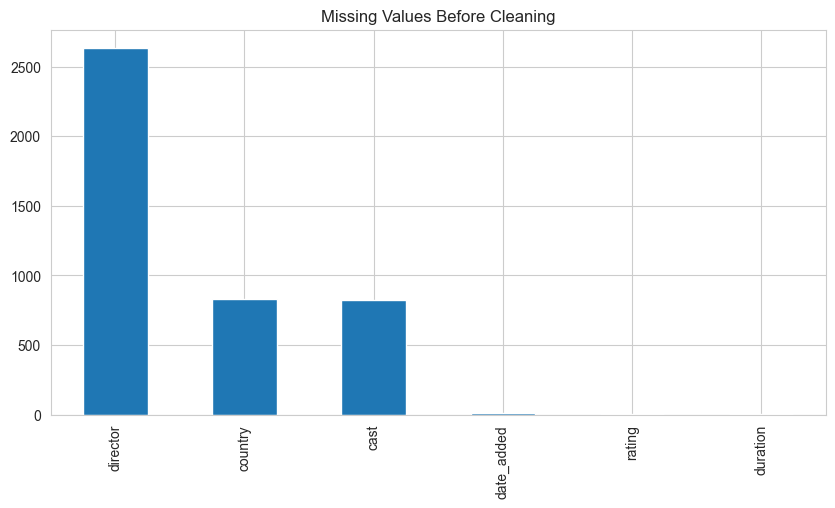

In [5]:
plt.figure(figsize=(10,5))

missing[missing > 0].plot(kind='bar')

plt.title("Missing Values Before Cleaning")

plt.savefig("missing_before.png", dpi=300, bbox_inches='tight')

plt.show()

### Handle Missing Values

In [6]:
# Fill categorical columns with 'Unknown'
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)

# Fill rating with mode
df['rating'].fillna(df['rating'].mode()[0], inplace=True)

# Drop rows where date_added is missing (important column)
df.dropna(subset=['date_added'], inplace=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_19816\972406153.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna('Unknown', inplace=True)
C:\Users\hp\AppData\Local\Temp\ipykernel_19816\972406153.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when

### Checking Missing values Again

In [7]:
missing_after = df.isnull().sum().sort_values(ascending=False)
missing_after

duration        3
show_id         0
title           0
type            0
director        0
cast            0
date_added      0
country         0
release_year    0
rating          0
listed_in       0
description     0
dtype: int64

### Visualize After Cleaning

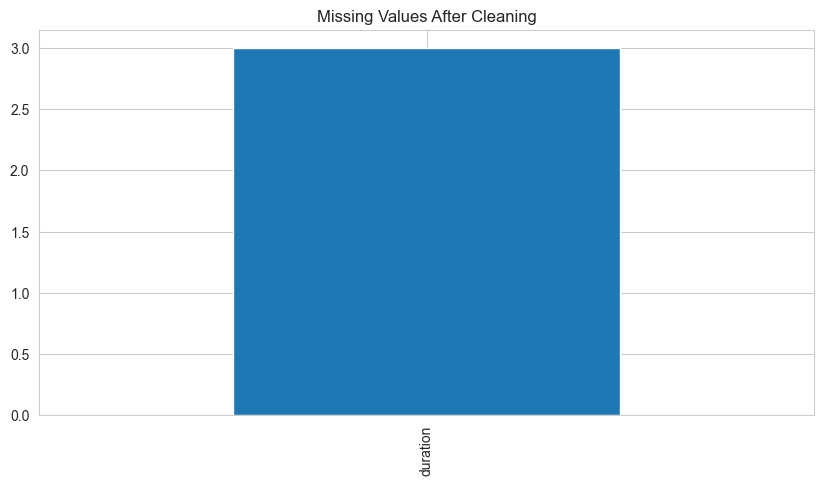

In [8]:
plt.figure(figsize=(10,5))

missing_after[missing_after > 0].plot(kind='bar')

plt.title("Missing Values After Cleaning")

plt.savefig("missing_after.png", dpi=300, bbox_inches='tight')

plt.show()

### Converting Data Types

In [10]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

### Feature Engineering

In [11]:
df['year_added'] = df['date_added'].dt.year

### Visualize Year Added Trend

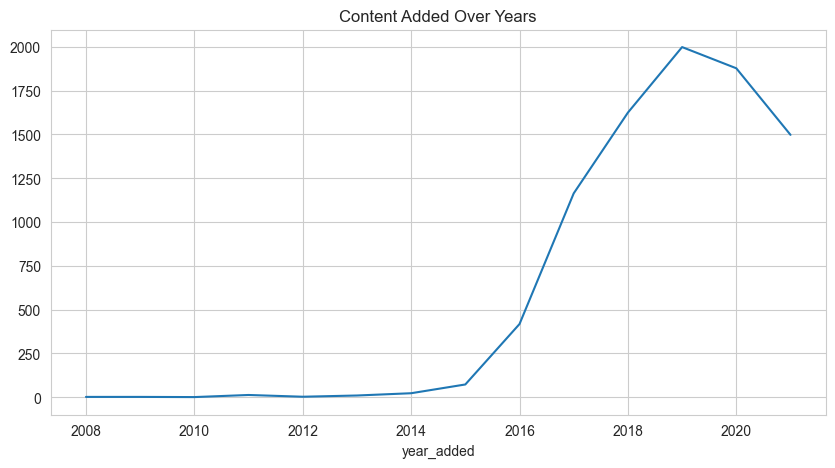

In [12]:
plt.figure(figsize=(10,5))

df['year_added'].value_counts().sort_index().plot()

plt.title("Content Added Over Years")

plt.savefig("year_added_trend.png", dpi=300, bbox_inches='tight')

plt.show()

### Removing Duplicates

In [13]:
df.drop_duplicates(inplace=True)

### Saving Cleaned Dataset

In [14]:
df.to_csv("netflix_cleaned.csv", index=False)

# My observations

### Missing values in director, cast, and country were filled with 'Unknown'
### Rating column was filled using mode
### Rows with missing date_added were removed
### New feature ‘year_added’ was created for better analysis
### Dataset is now clean and ready for EDA